In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy * 100)

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9985 - loss: 0.0026


In [ ]:

import os
os.listdir('/content/drive/MyDrive')

In [ ]:

import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction complete!")

Extraction complete!


In [ ]:

import os
print(os.listdir('/content/dataset'))

['leapgestrecog', 'leapGestRecog']


In [ ]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:

dataset_path = "/content/dataset/leapGestRecog"

images = []
labels = []

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    for gesture in os.listdir(person_path):
        gesture_path = os.path.join(person_path, gesture)

        for img in os.listdir(gesture_path):
            img_path = os.path.join(gesture_path, img)

            image = cv2.imread(img_path)
            image = cv2.resize(image, (64,64))

            images.append(image)
            labels.append(gesture)

print("Images Loaded:", len(images))

Images Loaded: 20000


In [ ]:

images = np.array(images) / 255.0
labels = np.array(labels)

encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

labels_categorical = to_categorical(labels_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_categorical,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (16000, 64, 64, 3)
Testing samples: (4000, 64, 64, 3)


In [ ]:

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(labels_categorical.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 200ms/step - accuracy: 0.8954 - loss: 0.3221 - val_accuracy: 0.9987 - val_loss: 0.0054
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - accuracy: 0.9905 - loss: 0.0322 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 199ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 1.7438e-04
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 96s 193ms/step - accuracy: 0.9954 - loss: 0.0153 - val_accuracy: 1.0000 - val_loss: 2.2349e-04
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 108s 216ms/step - accuracy: 0.9938 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 2.9462e-04
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 195ms/step - accuracy: 0.9956 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 2.2100e-04
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 202ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 1.5734e-04
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 98s 196ms/step - 

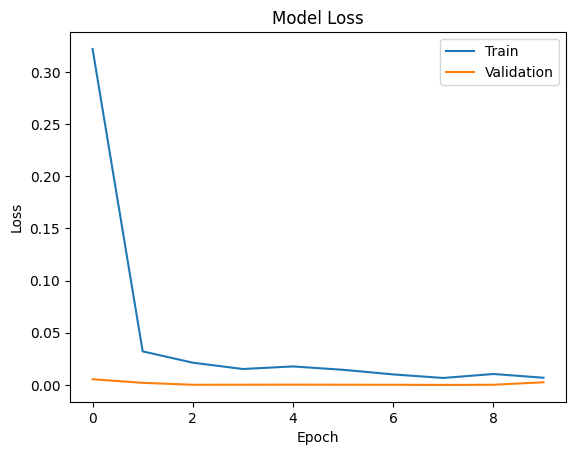

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       404
           1       1.00      1.00      1.00       409
           2       1.00      1.00      1.00       366
           3       1.00      1.00      1.00       392
           4       1.00      1.00      1.00       377
           5       1.00      1.00      1.00       403
           6       1.00      1.00      1.00       418
           7       1.00      0.99      0.99       417
           8       0.99      1.00      0.99       404
           9       1.00      1.00      1.00       410

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



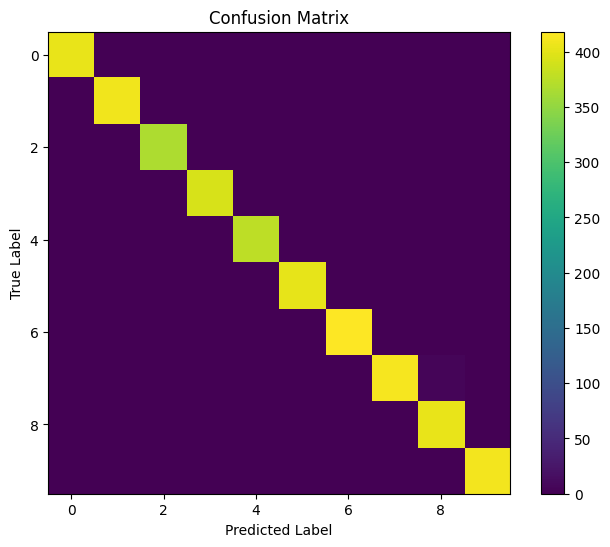

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
model.save("gesture_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("gesture_model.h5")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
print(encoder.classes_)

['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


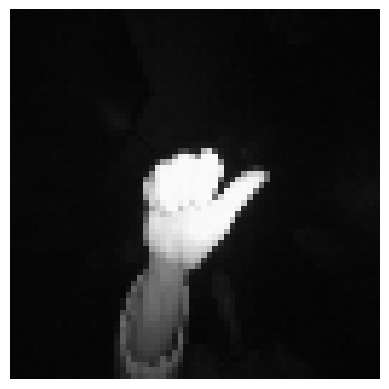

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Predicted Gesture: 05_thumb
Actual Gesture: 05_thumb


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

index = 50

plt.imshow(X_test[index])
plt.axis('off')
plt.show()

prediction = loaded_model.predict(np.expand_dims(X_test[index], axis=0))
pred = np.argmax(prediction)
actual = np.argmax(y_test[index])

print("Predicted Gesture:", encoder.classes_[pred])
print("Actual Gesture:", encoder.classes_[actual])